# 금융 데이터 다루기

# yfinance (Yahoo Finance API)
- 설명 : Yahoo Finance에서 주식 데이터를 가져오는 라이브러리
- 설치: `pip install yfinance`
- 주요 기능
    - 주식 정보 조회: 개별 주식의 과거 가격 데이터, 배당금 정보, 분할 정보 등을 조회할 수 있다.
    - 금융 데이터 다운로드: 일별, 주별, 월별 시계열 데이터를 Pandas DataFrame 형태로 쉽게 다운로드할 수 있다.
    - 다양한 금융 지표 제공: 시가, 고가, 저가, 종가, 거래량 등 주식 시장의 다양한 지표를 제공한다.
    - 복수 종목 데이터 동시 조회: 여러 주식 종목의 데이터를 한 번에 조회하는 기능을 지원한다.


## 1.1.yfinance 설치

- https://pypi.org/project/yfinance/

In [20]:
# %pip install yfinance
# uv add yfinance

In [1]:
import yfinance as yf
print(yf.__version__)

1.4.1


## 1.2.주식 데이터 가져오기

In [2]:
stock = yf.download('042700.KS', start='2022-01-01', end='2026-06-03')
stock = stock.reset_index()

stock.columns = stock.columns.droplevel(1)
stock.tail()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
1070,2026-05-27,319000.0,354000.0,312000.0,350500.0,1860431
1071,2026-05-28,292500.0,313000.0,284000.0,313000.0,1395171
1072,2026-05-29,282000.0,301000.0,277500.0,301000.0,1603208
1073,2026-06-01,293000.0,299000.0,285500.0,289500.0,1225560
1074,2026-06-02,275500.0,296500.0,273000.0,295500.0,1077612


In [3]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1075 entries, 0 to 1074
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1075 non-null   datetime64[ns]
 1   Close   1075 non-null   float64       
 2   High    1075 non-null   float64       
 3   Low     1075 non-null   float64       
 4   Open    1075 non-null   float64       
 5   Volume  1075 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 50.5 KB


In [5]:
stock_info = yf.Ticker('042700.KS')
stock_info.info

{'address1': '14, Gajwa-ro 30 beon-gil',
 'address2': 'Seo-gu',
 'city': 'Incheon',
 'country': 'South Korea',
 'phone': '82 3 2571 9100',
 'fax': '82 3 2578 5557',
 'website': 'https://www.hanmisemi.com',
 'industry': 'Semiconductor Equipment & Materials',
 'industryKey': 'semiconductor-equipment-materials',
 'industryDisp': 'Semiconductor Equipment & Materials',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'HANMI Semiconductor Co., Ltd. manufactures and sells semiconductor equipment in South Korea and internationally. The company offers bonder; micro SAW equipment; vision placement equipment; meta grinder; EMI shield vision attach and detach, EMI shield vision placement, EMI shield tape mounter, EMI shield tape laser cutting, EMI shield tape demounter, vision inspection, and converlay attach equipment; laser marking, laser ablation, and laser cutting equipment; and pick and place, strip mounter, and vision inspection equipm

- 특정 기간의 주가 데이터 가져오기

In [10]:
# 최근 3년 데이터를 간단히 가져옴
# start, end로 기간을 지정하지 않아도 됨
stock1 = stock_info.history(period='3y')
stock1 = stock1.reset_index()
stock1

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2023-06-05 00:00:00+09:00,25009.900674,25157.596938,24566.811883,24763.740234,2280681,0.0,0.0
1,2023-06-07 00:00:00+09:00,24763.741191,25009.901641,24419.116562,24616.044922,1751275,0.0,0.0
2,2023-06-08 00:00:00+09:00,24271.418810,25403.756807,24123.722550,25256.060547,2778389,0.0,0.0
3,2023-06-09 00:00:00+09:00,25502.221474,26536.095318,24960.668508,26191.470703,4478632,0.0,0.0
4,2023-06-12 00:00:00+09:00,26486.864534,26536.096624,25649.919001,26093.007812,1663874,0.0,0.0
...,...,...,...,...,...,...,...,...
723,2026-05-28 00:00:00+09:00,313000.000000,313000.000000,284000.000000,292500.000000,1395171,0.0,0.0
724,2026-05-29 00:00:00+09:00,301000.000000,301000.000000,277500.000000,282000.000000,1603208,0.0,0.0
725,2026-06-01 00:00:00+09:00,289500.000000,299000.000000,285500.000000,293000.000000,1225560,0.0,0.0
726,2026-06-02 00:00:00+09:00,295500.000000,296500.000000,273000.000000,275500.000000,1077612,0.0,0.0


## 1.3.주가 데이터 시각화

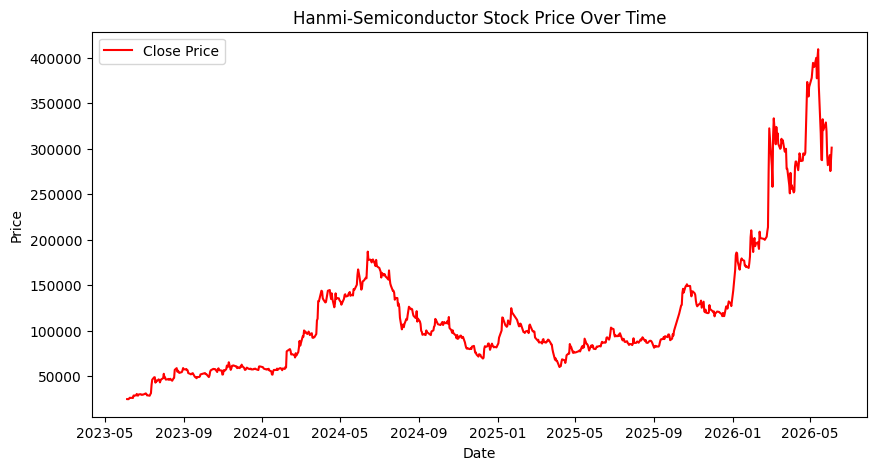

In [13]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))
plt.plot(stock1['Date'], stock1['Close'], label='Close Price', color='red')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Hanmi-Semiconductor Stock Price Over Time')
plt.legend()
plt.show()

In [14]:
# 캔들 차트로 그리기
import plotly.graph_objects as go
import plotly.express as px



fig = go.Figure(data=[go.Candlestick(x=stock1['Date'],
                                     open=stock1['Open'],
                                     high=stock1['High'],
                                     low=stock1['Low'],
                                     close=stock1['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

## 1.4.LSTM으로 주식 예측하기

In [19]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

In [16]:
# 종가만 사용
close_prices = stock1['Close']
close_prices

0       24763.740234
1       24616.044922
2       25256.060547
3       26191.470703
4       26093.007812
           ...      
723    292500.000000
724    282000.000000
725    293000.000000
726    275500.000000
727    301250.000000
Name: Close, Length: 728, dtype: float64

In [17]:
# 데이터 스케일링
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(close_prices.values.reshape(-1, 1))

In [20]:
# 시퀀스 데이터 생성
sequence_length = 20
X, y = [], []

for i in range(len(scaled_data) - sequence_length):
    X.append(scaled_data[i:i+sequence_length])
    y.append(scaled_data[i+sequence_length])

X, y = np.array(X), np.array(y)

In [21]:
# 데이터 분할
# 시간 순서를 유지한 채로 앞 80%는 학습, 뒤 20% 테스트로 나눔.
# 시계열에서는 미래 데이터가 학습에 섞이지 않도록 무작위 분할을 피하는 것이 중요.
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [22]:
# 텐서 변환
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

In [ ]:
# 데이터 로더 생성
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

: 